In [1]:
%pip install -q librosa soundfile pandas matplotlib seaborn scikit-learn

In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import librosa
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import ASTFeatureExtractor, ASTForAudioClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cuda":
    print("Tip: Runtime > Change runtime type > GPU is recommended for AST fine-tuning.")

Device: cuda


In [5]:
DATA_DIR = Path("/content/ESC-50")
if not (DATA_DIR / "meta" / "esc50.csv").exists():
    !git clone https://github.com/karolpiczak/ESC-50.git /content/ESC-50

Cloning into '/content/ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 14.99 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [6]:
metadata = pd.read_csv(DATA_DIR / "meta" / "esc50.csv")
classes = sorted(metadata["category"].unique())
class_to_idx = {name: idx for idx, name in enumerate(classes)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

Classes: 50
Train: 1200 | Validation: 400 | Test: 400


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [7]:
train_df = metadata[metadata["fold"].isin([1, 2, 3])].reset_index(drop=True)
val_df = metadata[metadata["fold"] == 4].reset_index(drop=True)
test_df = metadata[metadata["fold"] == 5].reset_index(drop=True)

In [8]:
print("Classes:", len(classes))
print("Train:", len(train_df), "| Validation:", len(val_df), "| Test:", len(test_df))
display(metadata.head())

Classes: 50
Train: 1200 | Validation: 400 | Test: 400


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [9]:
MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"
SAMPLE_RATE = 16000
AUDIO_SECONDS = 10
MAX_SAMPLES = SAMPLE_RATE * AUDIO_SECONDS
BATCH_SIZE = 8 if device.type == "cuda" else 2
EPOCHS = 15
PATIENCE = 4

In [10]:
feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_NAME)
model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(classes),
    ignore_mismatched_sizes=True,
    label2id=class_to_idx,
    id2label=idx_to_class
)
model.to(device)
print("Model loaded:", MODEL_NAME)
print("Batch size:", BATCH_SIZE)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=50` which is incompatible to the `id2label` map of length `527`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([50, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([50])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded: MIT/ast-finetuned-audioset-10-10-0.4593
Batch size: 8


In [11]:
def load_audio(path):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    if len(audio) > MAX_SAMPLES:
        audio = audio[:MAX_SAMPLES]
    elif len(audio) < MAX_SAMPLES:
        audio = np.pad(audio, (0, MAX_SAMPLES - len(audio)))
    return audio.astype(np.float32)

In [12]:
class ESC50ASTDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        self.features = []
        self.labels = []
        for row in self.df.itertuples(index=False):
            path = DATA_DIR / "audio" / row.filename
            audio = load_audio(path)
            encoded = feature_extractor(
                audio,
                sampling_rate=SAMPLE_RATE,
                padding="max_length",
                truncation=True,
                max_length=1024,
                return_tensors="pt"
            )
            self.features.append(encoded["input_values"].squeeze(0))
            self.labels.append(class_to_idx[row.category])
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_values": self.features[idx],
            "labels": self.labels[idx]
        }

In [13]:
train_dataset = ESC50ASTDataset(train_df)
val_dataset = ESC50ASTDataset(val_df)
test_dataset = ESC50ASTDataset(test_df)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [15]:
batch = next(iter(train_loader))
print("Input batch shape:", batch["input_values"].shape)
print("Label batch shape:", batch["labels"].shape)

Input batch shape: torch.Size([8, 1024, 128])
Label batch shape: torch.Size([8])


In [16]:
from torch.optim import AdamW
from tqdm.auto import tqdm

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": [], "val_macro_f1": []}
best_val_f1 = -1.0
best_state = None
epochs_without_improvement = 0
BEST_PATH = "/content/best_esc50_ast.pth"

In [17]:
for epoch in range(EPOCHS):
    model.train()
    train_losses, train_true, train_pred = [], [], []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} train", leave=False):
        inputs = batch["input_values"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            outputs = model(input_values=inputs, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())
        train_pred.extend(outputs.logits.argmax(dim=1).detach().cpu().tolist())
        train_true.extend(labels.detach().cpu().tolist())

    model.eval()
    val_losses, val_true, val_pred = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch["input_values"].to(device)
            labels = batch["labels"].to(device)
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                outputs = model(input_values=inputs, labels=labels)
            val_losses.append(outputs.loss.item())
            val_pred.extend(outputs.logits.argmax(dim=1).cpu().tolist())
            val_true.extend(labels.cpu().tolist())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    train_acc = accuracy_score(train_true, train_pred)
    val_acc = accuracy_score(val_true, val_pred)
    val_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)
    history["val_macro_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.3f} | "
        f"Val Acc: {val_acc:.3f} | Val Macro-F1: {val_f1:.3f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, BEST_PATH)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping: validation macro-F1 did not improve.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"Best validation macro-F1: {best_val_f1:.4f}")
print("Checkpoint:", BEST_PATH)

Epoch 1/15 train:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 1.4582 | Val Loss: 0.4565 | Train Acc: 0.732 | Val Acc: 0.880 | Val Macro-F1: 0.870


Epoch 2/15 train:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 02/15 | Train Loss: 0.1236 | Val Loss: 0.2050 | Train Acc: 0.977 | Val Acc: 0.948 | Val Macro-F1: 0.947


Epoch 3/15 train:   0%|          | 0/150 [00:00<?, ?it/s]

...

Epoch 10/15 | Train Loss: 0.0002 | Val Loss: 0.1448 | Train Acc: 1.000 | Val Acc: 0.960 | Val Macro-F1: 0.960


Epoch 11/15 train:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 11/15 | Train Loss: 0.0002 | Val Loss: 0.1451 | Train Acc: 1.000 | Val Acc: 0.963 | Val Macro-F1: 0.962


Epoch 12/15 train:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 12/15 | Train Loss: 0.0002 | Val Loss: 0.1457 | Train Acc: 1.000 | Val Acc: 0.963 | Val Macro-F1: 0.962
Early stopping: validation macro-F1 did not improve.
Best validation macro-F1: 0.9625
Checkpoint: /content/best_esc50_ast.pth


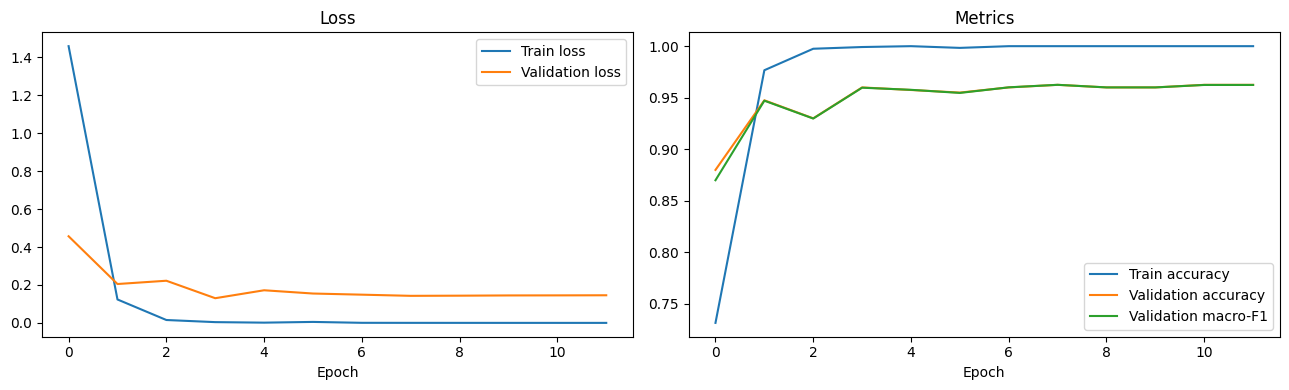

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="Train loss")
axes[0].plot(history["val_loss"], label="Validation loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_accuracy"], label="Train accuracy")
axes[1].plot(history["val_accuracy"], label="Validation accuracy")
axes[1].plot(history["val_macro_f1"], label="Validation macro-F1")
axes[1].set_title("Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

In [19]:
model.eval()

ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ASTLayer(
        (attention): ASTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ASTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Li

In [20]:
all_labels, all_preds = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        inputs = batch["input_values"].to(device)
        labels = batch["labels"].to(device)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            logits = model(input_values=inputs).logits
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

Testing:   0%|          | 0/50 [00:00<?, ?it/s]

In [21]:
test_accuracy = accuracy_score(all_labels, all_preds)
test_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
print(f"Test accuracy: {test_accuracy:.2%}")
print(f"Test macro-F1: {test_macro_f1:.4f}")
print(classification_report(
    all_labels, all_preds,
    labels=list(range(len(classes))),
    target_names=classes,
    zero_division=0,
    digits=3
))

Test accuracy: 93.50%
Test macro-F1: 0.9325
                  precision    recall  f1-score   support

        airplane      0.667     0.500     0.571         8
       breathing      1.000     1.000     1.000         8
  brushing_teeth      1.000     1.000     1.000         8
     can_opening      1.000     0.875     0.933         8
        car_horn      1.000     1.000     1.000         8
             cat      0.889     1.000     0.941         8
        chainsaw      0.875     0.875     0.875         8
  chirping_birds      1.000     1.000     1.000         8
    church_bells      1.000     1.000     1.000         8
        clapping      0.889     1.000     0.941         8
     clock_alarm      1.000     1.000     1.000         8
      clock_tick      1.000     1.000     1.000         8
        coughing      1.000     0.875     0.933         8
             cow      1.000     1.000     1.000         8
  crackling_fire      1.000     0.750     0.857         8
        crickets      0.800

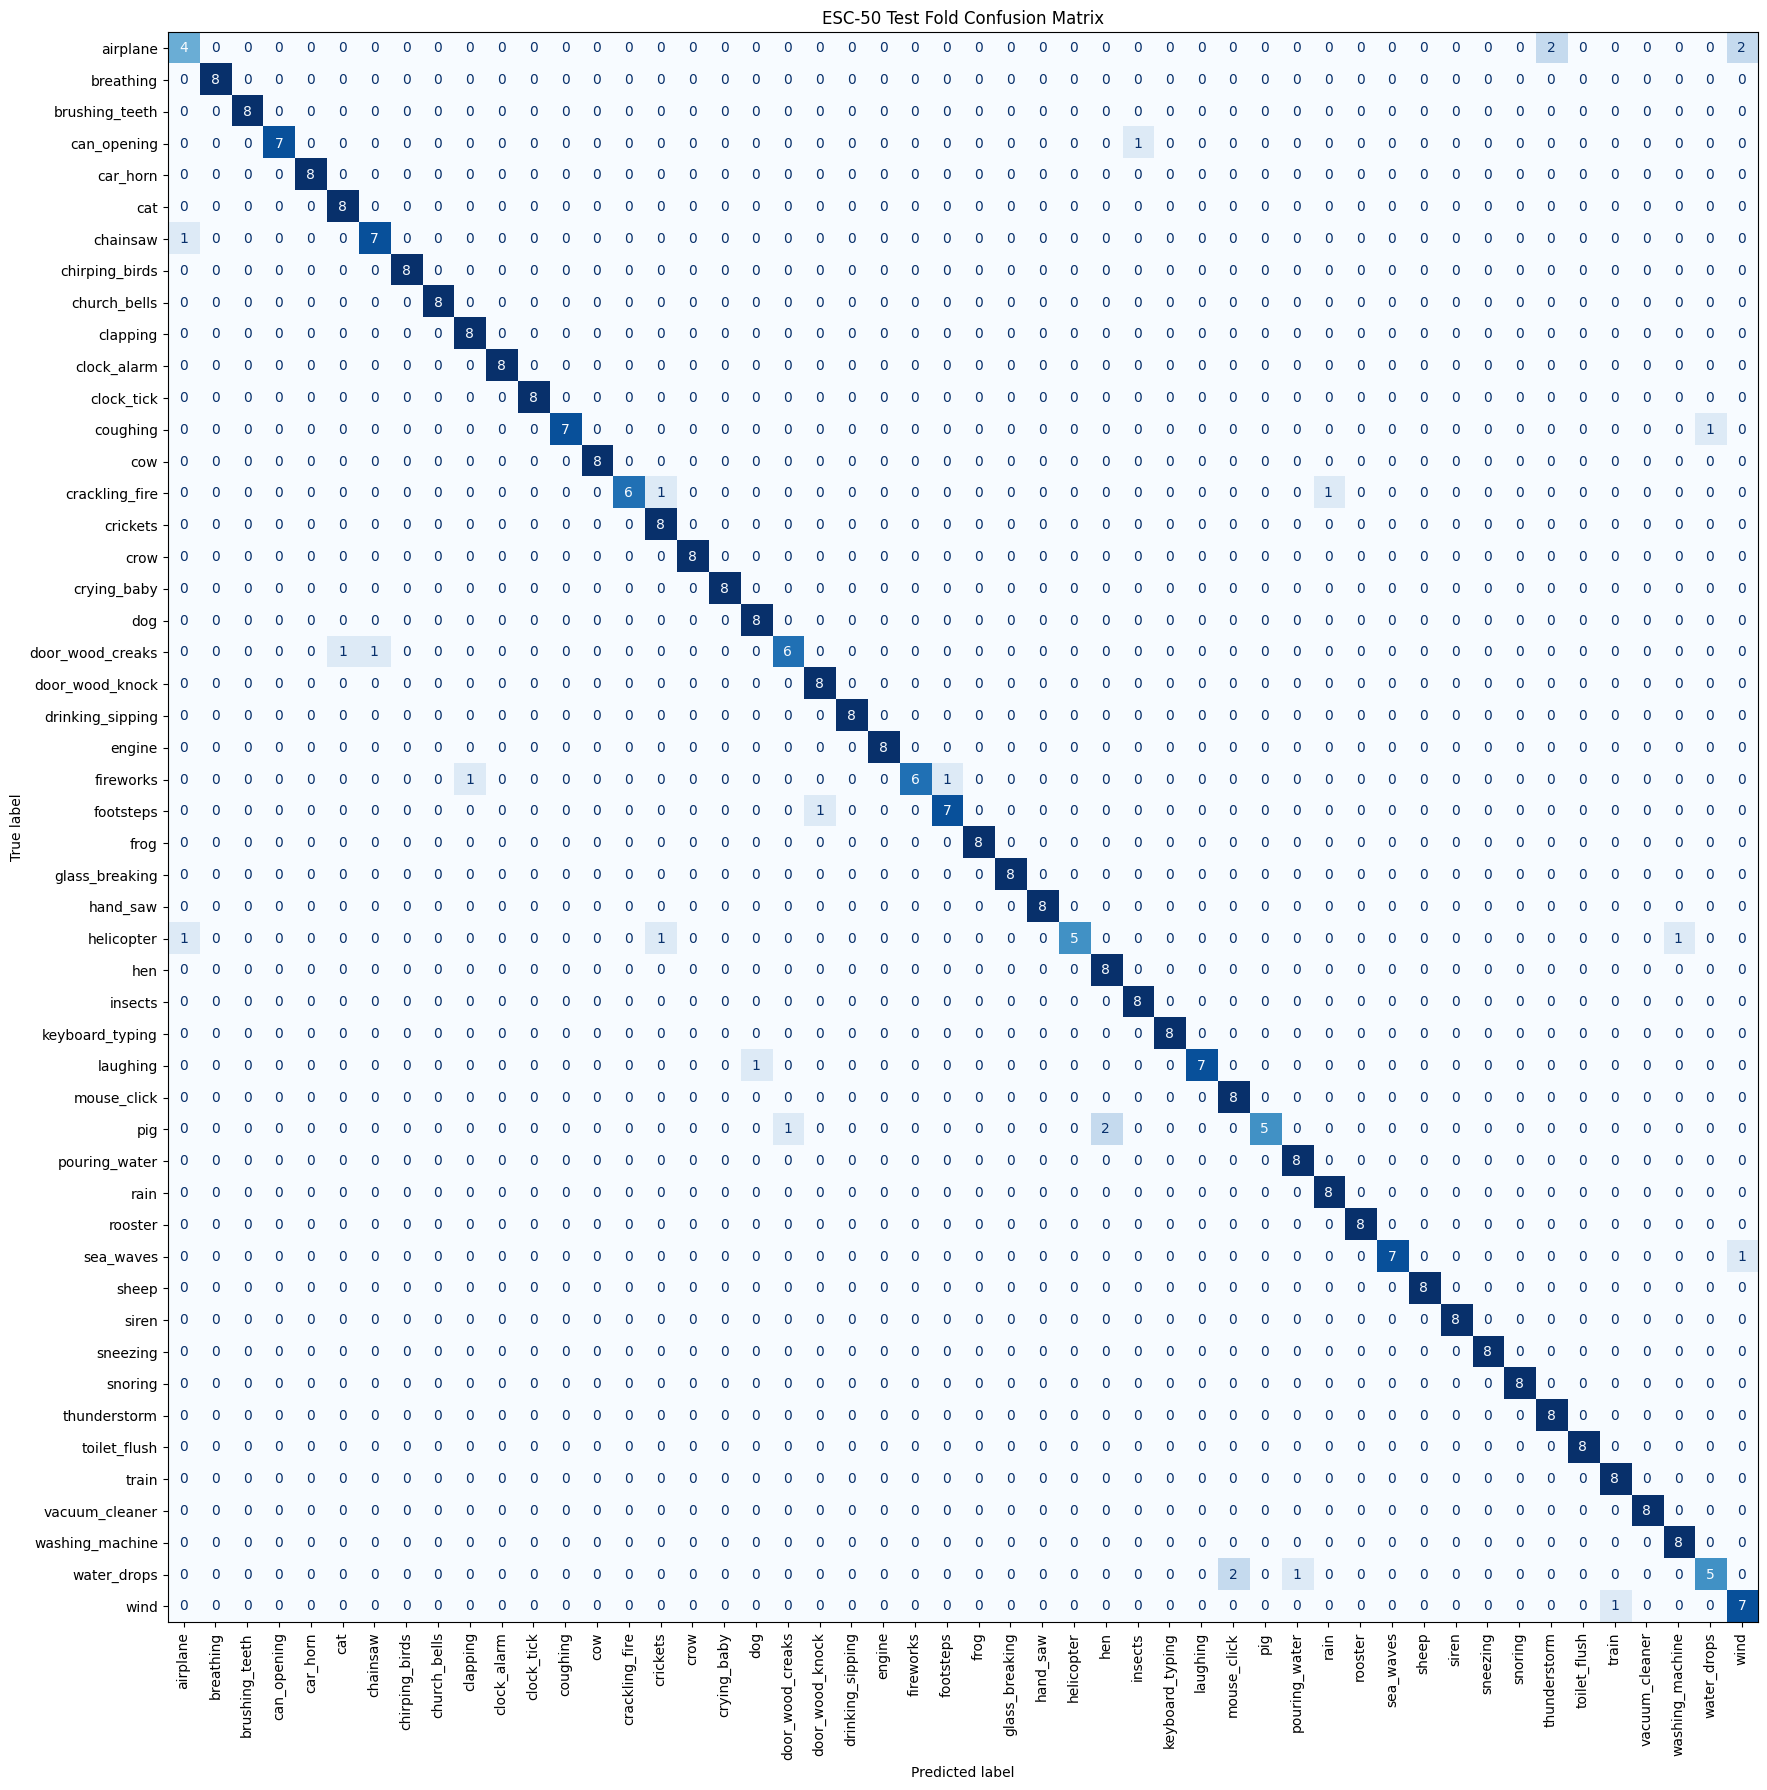

In [22]:
fig, ax = plt.subplots(figsize=(18, 18))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds,
    labels=list(range(len(classes))),
    display_labels=classes,
    xticks_rotation="vertical",
    cmap="Blues",
    colorbar=False,
    ax=ax
)
ax.set_title("ESC-50 Test Fold Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
from google.colab import files
import torch.nn.functional as F

Saving dragon-studio-dog-barking-406629.mp3 to dragon-studio-dog-barking-406629.mp3


In [24]:
uploaded = files.upload()
if not uploaded:
    raise ValueError("No audio file was uploaded.")

Saving dragon-studio-dog-barking-406629.mp3 to dragon-studio-dog-barking-406629 (1).mp3


In [25]:
filename = next(iter(uploaded))
audio = load_audio(filename)
encoded = feature_extractor(
    audio,
    sampling_rate=SAMPLE_RATE,
    padding="max_length",
    truncation=True,
    max_length=1024,
    return_tensors="pt"
)
input_values = encoded["input_values"].to(device)

In [26]:
model.eval()
with torch.no_grad():
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
        logits = model(input_values=input_values).logits
    probabilities = F.softmax(logits, dim=1)[0]

top_probs, top_indices = torch.topk(probabilities, k=5)
print("File:", filename)
for rank, (prob, idx) in enumerate(zip(top_probs.cpu().tolist(), top_indices.cpu().tolist()), start=1):
    print(f"{rank}. {idx_to_class[idx]} — {prob:.2%}")

File: dragon-studio-dog-barking-406629 (1).mp3
1. dog — 99.90%
2. cow — 0.01%
3. coughing — 0.01%
4. engine — 0.01%
5. chainsaw — 0.00%


In [27]:
import os
import torch
import pickle
from google.colab import files

checkpoint_path = "/content/best_esc50_ast.pth"
output_path = "/content/bestmodel.pkl"

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    with open(output_path, "wb") as f:
        pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("Model saved as bestmodel.pkl")
    files.download(output_path)
else:
    print("Checkpoint not found:", checkpoint_path)

Model saved as bestmodel.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>